DL ASSIGNMENT 1

*Building a CNN Model for Intel Image Classification*

## Import Required Libraries

 imports the essential Python libraries and frameworks needed for image classification, visualization, preprocessing, and deep learning.

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.20.0


## 2️⃣ Download Dataset from Kaggle

In [2]:

import json

# Replace with your Kaggle API credentials
kaggle_config = {
    "username": "vsmuhsina",
    "key": "KGAT_4b8c1bb5f9e2c1634ec5cba4004b1230"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_config, f)

print("kaggle.json created successfully")

kaggle.json created successfully


In [3]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!pip install -q kaggle

## Load and Explore Dataset

 loads the dataset paths and explores the dataset structure. It helps verify that the training, validation, and testing data are correctly organized.

In [5]:
# Intel Image Classification Dataset
!kaggle datasets download -d puneet6060/intel-image-classification


Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:05<00:00, 62.2MB/s]



In [6]:
!unzip intel-image-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: seg_train/seg_train/mountain/7506.jpg  
  inflating: seg_train/seg_train/mountain/7537.jpg  
  inflating: seg_train/seg_train/mountain/7539.jpg  
  inflating: seg_train/seg_train/mountain/7551.jpg  
  inflating: seg_train/seg_train/mountain/7560.jpg  
  inflating: seg_train/seg_train/mountain/7565.jpg  
  inflating: seg_train/seg_train/mountain/7578.jpg  
  inflating: seg_train/seg_train/mountain/7581.jpg  
  inflating: seg_train/seg_train/mountain/7586.jpg  
  inflating: seg_train/seg_train/mountain/7647.jpg  
  inflating: seg_train/seg_train/mountain/7652.jpg  
  inflating: seg_train/seg_train/mountain/7654.jpg  
  inflating: seg_train/seg_train/mountain/7662.jpg  
  inflating: seg_train/seg_train/mountain/767.jpg  
  inflating: seg_train/seg_train/mountain/7672.jpg  
  inflating: seg_train/seg_train/mountain/7679.jpg  
  inflating: seg_train/seg_train/mountain/7681.jpg  
  inflating: seg_train/seg_train/mountain/7693.jp

In [7]:
dataset_path = 'seg_train/seg_train'

classes = os.listdir(dataset_path)
print("Classes:", classes)
print("Number of Classes:", len(classes))

Classes: ['buildings', 'mountain', 'forest', 'sea', 'street', 'glacier']
Number of Classes: 6


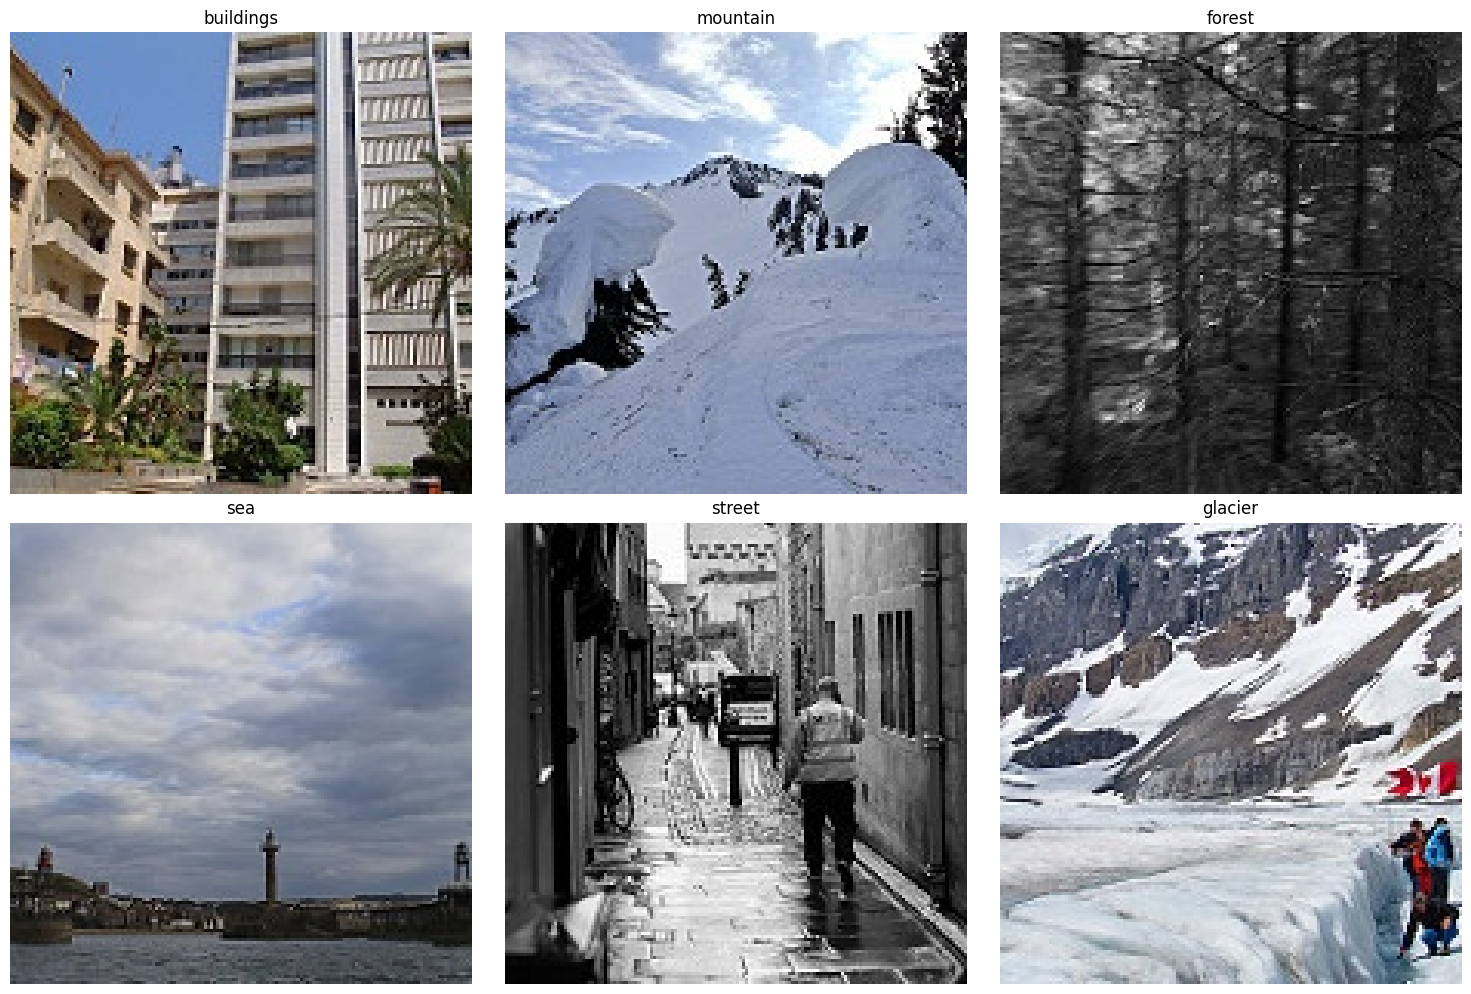

In [8]:
plt.figure(figsize=(15,10))

for i, class_name in enumerate(classes[:6]):
    image_name = random.choice(os.listdir(os.path.join(dataset_path, class_name)))
    image_path = os.path.join(dataset_path, class_name, image_name)

    img = plt.imread(image_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()


## 4️⃣ Data Preprocessing & Augmentation

his cell contains an important step in the Intel image classification workflow. Review the code and outputs carefully for better understanding.

In [9]:

IMG_SIZE = (150,150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [10]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    'seg_test/seg_test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


## Build the CNN Model

This section defines the Convolutional Neural Network (CNN) architecture used for image classification.

In [11]:
model = Sequential()

# Convolution Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Layer 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(6, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 6️⃣ Compile Model

This cell compiles the CNN model by defining the optimizer, loss function, and evaluation metrics.

In [12]:

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,564,998 (36.49 MB)

 Trainable params: 9,564,998 (36.49 MB)

 Non-trainable params: 0 (0.00 B)

## 7️⃣ Train Model

## Train the CNN Model

This section trains the CNN model using the prepared training dataset and validates its performance on validation data.


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_cnn_model.h5',
    monitor='val_accuracy',
    save_best_only=True
)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4496 - loss: 1.3601

351/351 ━━━━━━━━━━━━━━━━━━━━ 726s 2s/step - accuracy: 0.5355 - loss: 1.1799 - val_accuracy: 0.6405 - val_loss: 0.9558
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6124 - loss: 0.9875

351/351 ━━━━━━━━━━━━━━━━━━━━ 737s 2s/step - accuracy: 0.6276 - loss: 0.9634 - val_accuracy: 0.6847 - val_loss: 0.8522
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6653 - loss: 0.8928

351/351 ━━━━━━━━━━━━━━━━━━━━ 708s 2s/step - accuracy: 0.6698 - loss: 0.8743 - val_accuracy: 0.7179 - val_loss: 0.7679
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7028 - loss: 0.8064

351/351 ━━━━━━━━━━━━━━━━━━━━ 708s 2s/step - accuracy: 0.7084 - loss: 0.7871 - val_accuracy: 0.7343 - val_loss: 0.7190
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7286 - loss: 0.7414

351/351 ━━━━━━━━━━━━━━━━━━━━ 728s 2s/step - accuracy: 0.7280 - loss: 0.7456 - val_accuracy: 0.7760 - val_loss: 0.6349
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7420 - loss: 0.7184

351/351 ━━━━━━━━━━━━━━━━━━━━ 694s 2s/step - accuracy: 0.7455 - loss: 0.7075 - val_accuracy: 0.7767 - val_loss: 0.6570
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 729s 2s/step - accuracy: 0.7578 - loss: 0.6737 - val_accuracy: 0.7732 - val_loss: 0.6314
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7664 - loss: 0.6462

351/351 ━━━━━━━━━━━━━━━━━━━━ 720s 2s/step - accuracy: 0.7720 - loss: 0.6323 - val_accuracy: 0.8049 - val_loss: 0.5646
Epoch 9/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7832 - loss: 0.6175

351/351 ━━━━━━━━━━━━━━━━━━━━ 708s 2s/step - accuracy: 0.7773 - loss: 0.6179 - val_accuracy: 0.8099 - val_loss: 0.5629
Epoch 10/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7816 - loss: 0.6022

351/351 ━━━━━━━━━━━━━━━━━━━━ 712s 2s/step - accuracy: 0.7868 - loss: 0.5933 - val_accuracy: 0.8274 - val_loss: 0.5094
Epoch 11/20
327/351 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.7961 - loss: 0.5588

## 8️⃣ Plot Accuracy and Loss Curves

## Visualize Sample Images

This section visualizes images from the dataset to better understand the image classes, dimensions, and variations in the data.

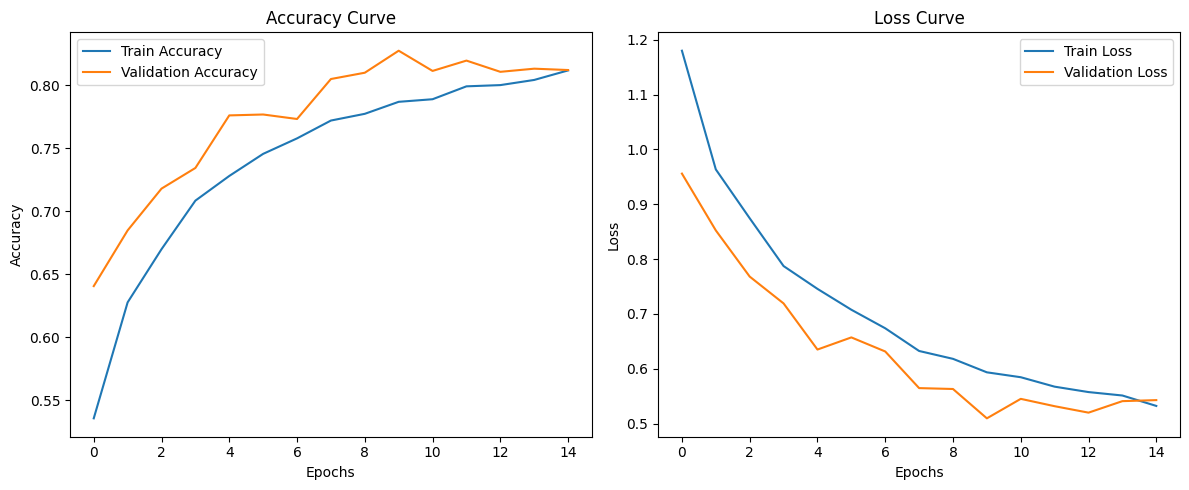

In [14]:

plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## 9️⃣ Evaluate Model

## Evaluate Model Performance

This cell evaluates the trained CNN model on the test dataset to measure its accuracy and loss.

In [15]:

test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

94/94 ━━━━━━━━━━━━━━━━━━━━ 49s 526ms/step - accuracy: 0.8480 - loss: 0.4433
Test Accuracy: 0.8479999899864197
Test Loss: 0.44334688782691956


## 🔟 Classification Report
## Make Predictions

This section uses the trained model to generate predictions for unseen images or test samples.

In [16]:

predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))



94/94 ━━━━━━━━━━━━━━━━━━━━ 45s 480ms/step
              precision    recall  f1-score   support

   buildings       0.80      0.83      0.82       437
      forest       0.95      0.97      0.96       474
     glacier       0.85      0.80      0.82       553
    mountain       0.83      0.75      0.79       525
         sea       0.82      0.86      0.84       510
      street       0.84      0.89      0.86       501

    accuracy                           0.85      3000
   macro avg       0.85      0.85      0.85      3000
weighted avg       0.85      0.85      0.85      3000



## 1️⃣1️⃣ Confusion Matrix



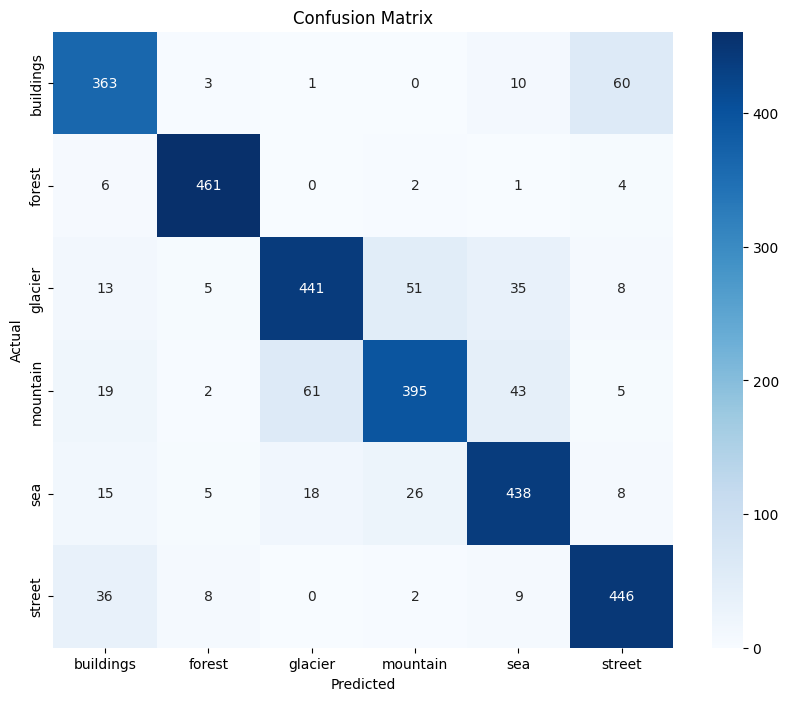

In [17]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 1️⃣2️⃣ Visualize Predictions
## Load and Explore Dataset

This cell loads the dataset paths and explores the dataset structure. It helps verify that the training, validation, and testing data are correctly organized.

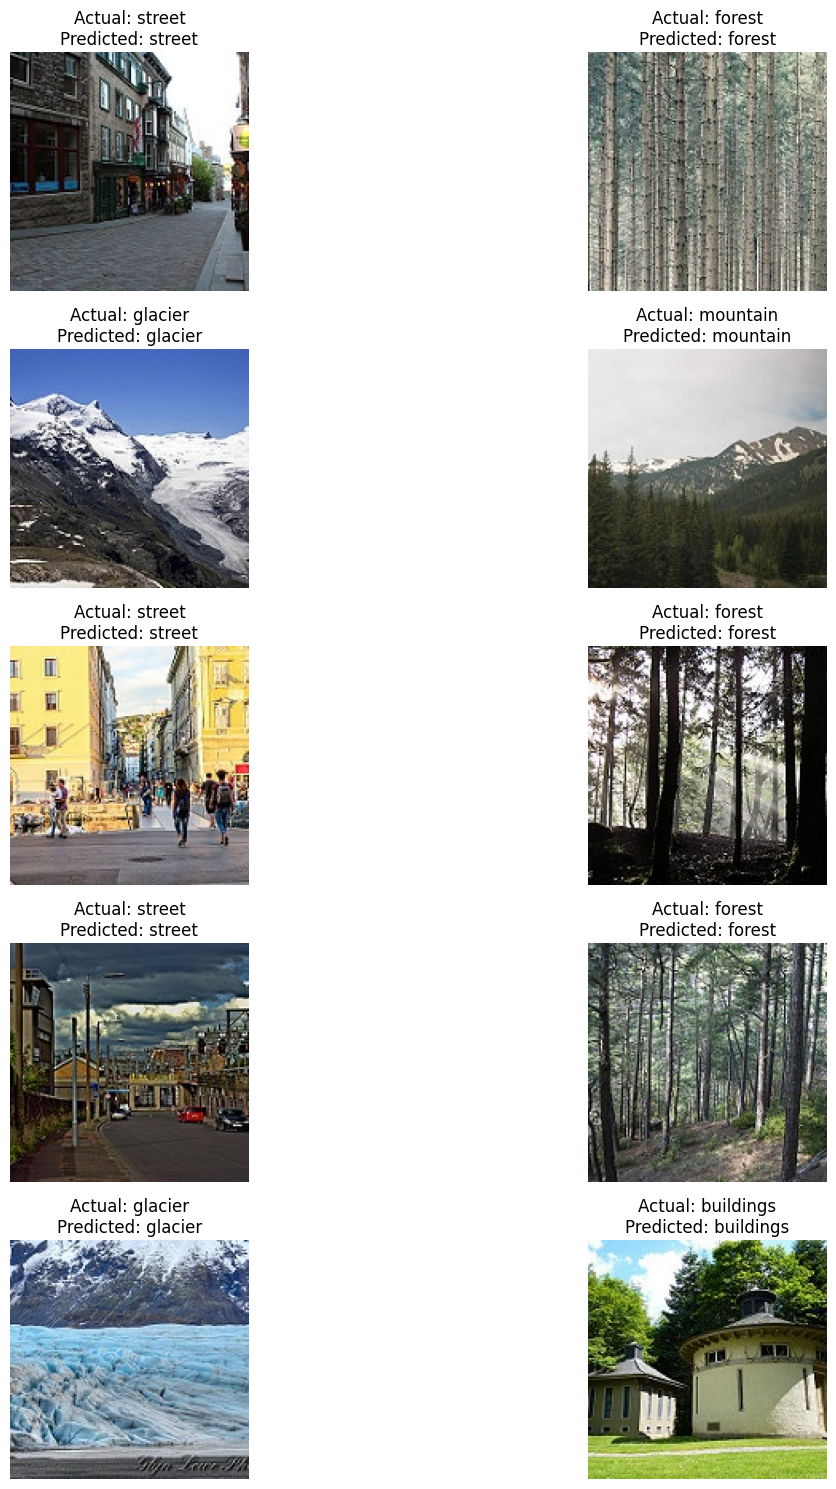

In [18]:

test_images_dir = 'seg_test/seg_test'

plt.figure(figsize=(15,15))

for i in range(10):
    class_name = random.choice(class_labels)
    image_name = random.choice(os.listdir(os.path.join(test_images_dir, class_name)))

    image_path = os.path.join(test_images_dir, class_name, image_name)

    img = tf.keras.preprocessing.image.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)
    predicted_label = class_labels[np.argmax(prediction)]

    plt.subplot(5,2,i+1)
    plt.imshow(img)
    plt.title(f"Actual: {class_name}\nPredicted: {predicted_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()